# **Simple DNN for Text Classification**  

In this notebook, we will explore how to build and train a **Simple Deep Neural Network (DNN)** for text classification. Unlike RNNs or CNNs, a DNN consists of fully connected **dense layers**, making it a straightforward yet powerful approach for classification tasks.  

A **DNN** is **faster to train** than RNNs because it processes input **in parallel** instead of sequentially. When combined with pretrained embeddings or good text representations, it can efficiently learn patterns for multi-class text classification.  

### **Objective & Steps:**  

In this notebook, we will:

- **Import** the preprocessed text data (tokenized, padded, and encoded from a previous notebook).
- **Build** a baseline **Simple DNN model** for text classification.
- **Train** the model on the training data — this step includes automatic **model checkpointing** to save the best version.
- **Evaluate** performance on the validation set using custom classification metrics and visualizations.
- **Export** a full classification analysis (F1 scores, misclassification insights, confusion matrix) into an Excel file for structured review.
- **(Optional)** Explore basic hyperparameter tuning, depending on computational resources.



## 1. Import Required Libraries 

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
import os
import json
import pandas as pd
import numpy as np
import pickle


# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Sequential, layers, backend as K
from tensorflow.keras.layers import Embedding, Dense, GlobalMaxPooling1D, GlobalAveragePooling1D, RNN, Conv1D, Dropout, SpatialDropout1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping


# Machine Learning & Model Evaluation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scikeras.wrappers import KerasClassifier



import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

from pathlib import Path
import importlib
import itertools
from datetime import datetime

# Setup dynamic project paths
CURRENT_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = CURRENT_DIR.parents[2]
sys.path.append(str(PROJECT_ROOT))

def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

print(f"Project Root Directory: {PROJECT_ROOT.name}")

# Load project config and modules from src
import config


Project Root Directory: Data_Scientist_Rakuten_Project-main


## 2. Data import and Preprocessing

We will import the preprocessed text data for the sanity check, including the original training dataset split into training and validation sets, followed by the loading of the tokenized and padded datasets used for deep learning training and inference. The data we are importing includes:

✔ **`X_train_split.pkl`** → The training dataset split. Contains text data columns: `designation`, `description`, `text` and the encoded target label (`prdtypecode_encoded`).<br>✔ **`X_val_split.pkl`** → The validation dataset split. Contains text data columns: `designation`, `description`, `text` and the encoded target label (`prdtypecode_encoded`).<br>✔ **`prdtypecode_mapping.pkl`** → The mapping for product type codes, from the original product code to values between 0-26.  
✔ **`X_train_pad_dl.pkl`** → Tokenized and padded training dataset.  
✔ **`X_val_pad_dl.pkl`** → Tokenized and padded validation dataset.  
✔ **`tokenizer_dl.pkl`** → The trained tokenizer, ensuring consistent preprocessing during model inference.


In [2]:
 ### 2.1 Import data

In [3]:
import src.data_preprocessing.data_loader
importlib.reload(src.data_preprocessing.data_loader)
from src.data_preprocessing.data_loader import load_splitted_data,load_tokenized_text_data
from sklearn.utils.class_weight import compute_class_weight

# Call the function
print("Load training split, validation split, and product code mapping.")
X_train_split, X_val_split, prdtypecode_mapping = load_splitted_data(2)



# Call the function
print(f"\nLoaded tokenized and padded training and validation data with a preview of the first specified samples.")
train_data, val_data, tokenizer= load_tokenized_text_data(5)



y_train = X_train_split['prdtypecode_encoded'].values
y_val = X_val_split['prdtypecode_encoded'].values

print(f"\nTarget varibales ")
print('y_train')
print(y_train)
print('y_val')
print(y_val)

Load training split, validation split, and product code mapping.
[✔] Loaded `X_train_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
1887,porte bebe violet rouge trois mere multifoncti...,Porte bébé Violet et rouge Trois-en-un mère mu...,porte bebe violet rouge trois mere multifoncti...,3050424970,1187504001,1320,12,Early Childhood,image_1187504001_product_3050424970.jpg
70389,jesus cahiers libre avenir,Prêtre autrement.,jesus cahiers libre avenir pretre autrement,131641431,885888766,10,0,Adult Books,image_885888766_product_131641431.jpg


[✔] Loaded `X_val_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
81432,bas filles enfants enfants collant coton bebe ...,Filles Bas Enfants Enfants Collant Coton bébé ...,bas filles enfants collant coton bebe stocking...,3898715946,1261369347,1301,10,Accessories for Children,image_1261369347_product_3898715946.jpg
44734,cosmic planete series peluche capuche couvertu...,Cosmic Planète Series en peluche avec capuche ...,cosmic planete series peluche capuche couvertu...,4205111198,1315322348,1560,13,Interior Furniture and Bedding,image_1315322348_product_4205111198.jpg


[✔] Loaded `prdtypecode_mapping` | Type: <class 'pandas.core.frame.DataFrame'>


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games



Loaded tokenized and padded training and validation data with a preview of the first specified samples.
[✔] Loaded `X_train_pad_dl` | Type: <class 'numpy.ndarray'>
[✔] Loaded `X_val_pad_dl` | Type: <class 'numpy.ndarray'>
[✔] Loaded `tokenizer_dl` | Type: <class 'keras.preprocessing.text.Tokenizer'>
Sample of X_train_pad_dl (first 5 samples):
[[ 132   64 1085 ...    0    0    0]
 [8443 4057  600 ...    0    0    0]
 [ 129 9285   46 ...    0    0    0]
 [  32  621  178 ...    0    0    0]
 [2917  660    1 ...    0    0    0]]

Sample of X_val_pad_dl (first 5 samples):
[[  333   509    17 ...     0     0     0]
 [16835  3001  1157 ...     0     0     0]
 [ 3113   638   306 ...     0     0     0]
 [    1   850    71 ...     0     0     0]
 [   47   282  2431 ...     0     0     0]]

Tokenizer preview (first 5 tokens):
[('<OOV>', 1), ('couleur', 2), ('taille', 3), ('haute', 4), ('qualite', 5)]

Target varibales 
y_train
[12  0 13 ...  5  0  5]
y_val
[10 13 23 ... 25 21 23]


 ### 2.2 Class Weights Calculation

In [4]:
class_labels = np.unique(X_train_split["prdtypecode_encoded"])
class_counts = {label: np.sum(X_train_split["prdtypecode_encoded"] == label) for label in class_labels}

print('\nclass_counts:')
print(class_counts)

# Compute class weights based on distribution
class_weights = compute_class_weight('balanced', classes=class_labels, y=X_train_split["prdtypecode_encoded"])
class_weight_dict = {class_labels[i]: class_weights[i] for i in range(len(class_labels))}
class_weight_dict = {int(key): value for key, value in class_weight_dict.items()}

for label, weight in list(class_weight_dict.items())[:5]:
    print(f"Class {label}: Adjusted weight: {weight}")


class_counts:
{0: 2493, 1: 2006, 2: 1345, 3: 666, 4: 2137, 5: 3162, 6: 611, 7: 3896, 8: 1656, 9: 4036, 10: 646, 11: 1993, 12: 2593, 13: 4058, 14: 3442, 15: 642, 16: 3994, 17: 659, 18: 3808, 19: 3819, 20: 1137, 21: 3991, 22: 2071, 23: 8167, 24: 1997, 25: 2209, 26: 698}
Class 0: Adjusted weight: 1.0092258323305254
Class 1: Adjusted weight: 1.2542372881355932
Class 2: Adjusted weight: 1.870631970260223
Class 3: Adjusted weight: 3.7777777777777777
Class 4: Adjusted weight: 1.1773514272344408


## 3. Simple Deep Neural Network (DNN) Model Construction  

In this step, we construct a **Simple DNN model** for text classification. Unlike RNNs or Conv1D models, a **DNN relies only on fully connected layers**, making it a straightforward yet effective approach.  

### **Model Architecture:**  
- **Embedding Layer**: Transforms words into dense vector representations.  
- **Flatten Layer**: Converts the 2D embedding matrix into a 1D feature vector.  
- **Dense Layer (100 units, ReLU activation)**: Learns high-level representations from the text data.  
- **Dropout Layer (0.5)**: Prevents overfitting by randomly deactivating neurons.  
- **Dense Output Layer**: Uses **softmax activation** to classify text into one of **27 categories**.  


In [6]:
# Import necessary libraries and modules
import src.modeling_text.text_model_builder
importlib.reload(src.modeling_text.text_model_builder)
from src.modeling_text.text_model_builder import create_model

# Check if num_words was set during training
if tokenizer.num_words is not None:
    vocab_size = tokenizer.num_words  # Use the predefined vocabulary limit
else:
    vocab_size = len(tokenizer.word_index) + 1  # Otherwise, use the full vocabulary

# Print vocabulary details separately
print(f"Tokenizer successfully loaded.")
print(f"Vocabulary size used (vocab_size): {vocab_size}")
print(f"Total words found in dataset: {len(tokenizer.word_index)}")

maxlen = max(len(seq) for seq in train_data)
print(f"Dynamic maxlen set to: {maxlen}")

embedding_dim = 100  # Dimensionality of the embedding vectors
max_sequence_length = maxlen  # Maximum length of the input sequences
num_classes = 27  # Number of output classes

# Create a DNN model
model = create_model(model_type="DNN", vocab_size=vocab_size, embedding_dim=embedding_dim, 
                     max_sequence_length=max_sequence_length, num_classes=num_classes)

model.summary()

Tokenizer successfully loaded.
Vocabulary size used (vocab_size): 20000
Total words found in dataset: 125362
Dynamic maxlen set to: 500
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 100)          2000000   
                                                                 
 flatten (Flatten)           (None, 50000)             0         
                                                                 
 dense (Dense)               (None, 100)               5000100   
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_1 (Dense)             (None, 27)                2727      
                                                                 
Total params: 7,002,827
Trainable params: 7,002,827


## 4. Model Compilation, Training, and Evaluation

Before fine-tuning, we begin with an **initial version** of our **1D Convolutional Neural Network (Conv1D)** for multi-class text classification to establish a **baseline** while keeping training time and computational cost manageable.

### Model Parameters

**Number of Epochs**: `EPOCHS = 40`  
- The model is trained for **up to 40 epochs**, but **early stopping** is applied to halt training when validation loss stops improving.  
- This ensures **optimal stopping** without overfitting.

**Early Stopping**:  
- **`monitor='val_loss'`** → Tracks validation loss to determine when to stop training.  
- **`patience=3`** → Training stops if validation loss does not improve for 3 consecutive epochs.  
- **`restore_best_weights=True`** → Restores the model weights from the epoch with the lowest validation loss.  

**Batch Size**: `BATCH_SIZE = 200`  
- A batch size of `200` balances **memory usage and convergence speed**.  
- Since **text sequences** can be long, this moderate batch size helps prevent excessive **GPU/CPU memory consumption**.

**Loss Function**: `sparse_categorical_crossentropy`  
- Best suited for **multi-class classification** with integer-labeled categories.

**Optimizer**: `Adam (learning_rate=0.001)`  
- **Adam** (Adaptive Moment Estimation) is used as it automatically adjusts the learning rate, making training faster and more efficient.
- We set `learning_rate=0.001`, which is the **default value**, though it can be fine-tuned.

**Metrics**: `accuracy` (excluding `weighted_f1` from `metrics`)  
- `accuracy` is a **quick and interpretable metric** for initial evaluation.  
- If the **custom `weighted_f1` function doesn't work properly**, the **Weighted F1-score will be computed manually** after evaluation to ensure accurate results.


### 4.1 Model Compilation and Training

In [7]:
# Additional parameters for training
#Quick text
# epochs = 1
# batch_size = 200
# learning_rate = 0.001

epochs = 40
batch_size = 200
learning_rate = 0.001

model_name = "simple_DNN_text_model"
save_model_dir = Path(config.NEURAL_MODELS_DIR)  # If None, it will use the default directory from config
# step_name = 'Step2'


In [8]:
%%time

from src.modeling_text.text_models_training import train_model_and_save 
importlib.reload(src.modeling_text.text_models_training)
from src.modeling_text.text_models_training import train_model_and_save


# Training the model
model, history = train_model_and_save(
        model=model,
        x_train = train_data,
        y_train=y_train,
        epochs=epochs,
        batch_size=batch_size,
        class_weight_dict=class_weight_dict,  # Apply class weights 
        x_val=val_data,
        y_val=y_val,
        #callbacks=callbacks_list
         model_name = model_name,
        save_model_dir = save_model_dir
    )



Epoch 1/40
340/340 [==============================] - ETA: 0s - loss: 2.5113 - accuracy: 0.2884
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
531/531 [==============================] - 1s 923us/step
Epoch 1: val_f1_score improved, saving model to ..\..\..\models\text\neural\simple_DNN_text_model_checkpoint.h5
340/340 [==============================] - 11s 12ms/step - loss: 2.5113 - accuracy: 0.2884 - val_loss: 1.1086 - val_accuracy: 0.7131 - val_f1_score: 0.7191
Epoch 2/40
333/340 [============================>.] - ETA: 0s - loss: 0.9443 - accuracy: 0.7332
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
531/531 [==============================] - 1s 999us/step
Epoch 2: val_f1_score improved, saving model to ..\..\..\models\text\neural\simple_DNN_text_model_checkpoint.h5
340/340 [==============================] - 3s 8ms/step - loss: 0.9429 - accuracy: 0.7337 - val_loss: 0.7447 - val_accuracy: 0.7863 - val

### 4.2 Learning Curve Analysis

#### 4.2.1 Display the Learning Curves

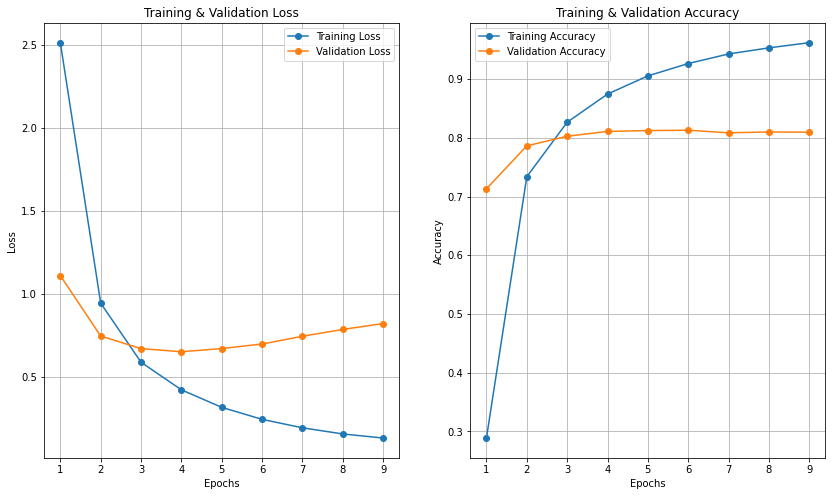

In [9]:
def plot_learning_curves(history):
    """
    Plots training & validation loss and accuracy over epochs.
    
    Args:
        history: Can be either:
            - A Keras `History` object (from model.fit())
            - A reloaded dictionary (from a JSON file)
    """

    # Check if `history` is a Keras History object
    if isinstance(history, tf.keras.callbacks.History):
        history_data = history.history  # Extract dictionary
    elif isinstance(history, dict):
        history_data = history  # Already a dictionary
    else:
        print("[X] Invalid `history` format. Expected a Keras History object or a dictionary.")
        return

    # Extract values
    epochs = range(1, len(history_data['loss']) + 1)
    train_loss = history_data['loss']
    val_loss = history_data['val_loss']
    train_acc = history_data['accuracy']
    val_acc = history_data['val_accuracy']

    # Plot Loss Curve
    plt.figure(figsize=(14, 8))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

# Example usage after training
plot_learning_curves(history)  # Works with a Keras History object



### 4.2.2 Interpretation of Learning Curves

#### **Training & Validation Loss**
- **Training loss continuously decreases**, indicating effective learning from the training set.
- **Validation loss decreases until around epoch 3, then begins to increase** → **clear sign of overfitting starting early**.

**Potential Solutions:**
- Use **early stopping** (currently `patience=5`) to stop training when validation performance starts to degrade. Based on the plot, reducing `patience` to **2 or 3** is recommended.
- Add or increase **dropout** or **L2 regularization** to reduce overfitting.
- Consider **textual data augmentation** (e.g., synonym replacement) to diversify the training set.

---

#### **Training & Validation Accuracy**
- **Training accuracy reaches ~97%**, while **validation accuracy plateaus around ~80% after epoch 3**.
- The widening **accuracy gap** indicates the model is **overfitting** to the training data.

**Potential Solutions:**
- Lower the **early stopping patience** (e.g., `patience=3`) for earlier stopping.
- Simplify the model by reducing **number of layers or hidden units**.
- Apply or increase **regularization**: dropout, weight decay, batch normalization.


### 4.3 Loading the Trained Model and Training History (Optional) 

In [12]:
# importlib.reload(config) #  Reload config to apply any updates

# # Ask the user for the model name to load
# model_name = "model_name_{...}.h5"  # Change this to the desired model filename

# # Define the full path to the model
# model_path = os.path.join(config.NEURAL_MODELS_DIR, model_name)

# # Automatically derive the history filename from the model name
# history_name = model_name.replace(".h5", "_history.json")  
# history_path = os.path.join(config.NEURAL_MODELS_DIR, history_name)

# # Load the model if the file exists
# if os.path.exists(model_path):
#     model = tf.keras.models.load_model(model_path)
#     print(f"✔ Model loaded successfully from: {model_path}")
# else:
#     print(f"[X] Model file not found at: {model_path}")
#     model = None  # Avoid errors if model is missing

# # Load the training history if the file exists
# if os.path.exists(history_path):
#     with open(history_path, "r") as f:
#         history = json.load(f)
#     print(f"✔ Training history loaded successfully from: {history_path}")
# else:
#     print(f"[X] Training history file not found at: {history_path}")
#     history = None  # Avoid errors if history is missing

### 4.4 Model Evaluation on the Test Set

531/531 [==============================] - 1s 3ms/step - loss: 0.6501 - accuracy: 0.8109
[✔] Test Loss: 0.6501
[✔] Test Accuracy: 0.8109
531/531 [==============================] - 1s 989us/step
[✔] Test Weighted F1-Score (computed manually): 0.8125

[✔] Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.59      0.49       623
           1       0.71      0.65      0.68       502
           2       0.80      0.83      0.81       336
           3       0.79      0.86      0.83       166
           4       0.75      0.79      0.77       534
           5       0.88      0.87      0.87       791
           6       0.54      0.65      0.59       153
           7       0.74      0.70      0.72       974
           8       0.63      0.55      0.59       414
           9       0.95      0.96      0.95      1009
          10       0.83      0.97      0.89       161
          11       0.81      0.75      0.78       498
          12       0

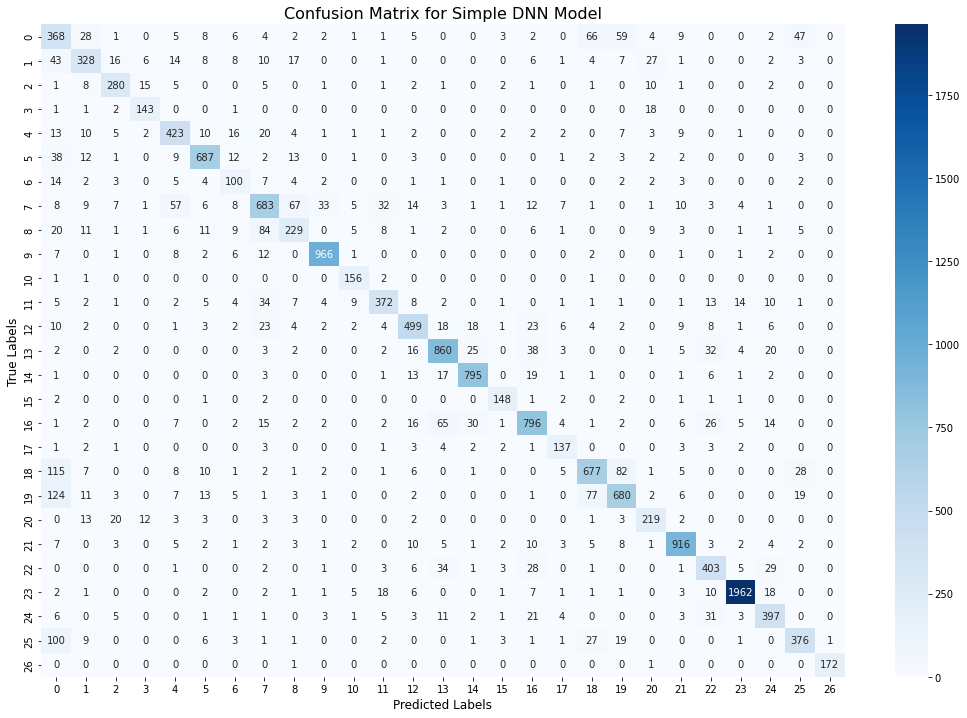

Wall time: 3.51 s


In [13]:
%%time

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(val_data, y_val)

# Print evaluation results
print(f"[✔] Test Loss: {test_loss:.4f}")
print(f"[✔] Test Accuracy: {test_accuracy:.4f}")

# Predict class probabilities on the test set
y_pred = model.predict(val_data)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=-1)

# Compute weighted F1-score manually
test_f1 = f1_score(y_val, y_pred_classes, average='weighted', zero_division=0)
print(f"[✔] Test Weighted F1-Score (computed manually): {test_f1:.4f}")

# Print classification report
print("\n[✔] Classification Report:")
print(classification_report(y_val, y_pred_classes,zero_division=0))

# Compute confusion matrix
# conf_matrix_df_raw = confusion_matrix(y_val, y_pred_classes)
conf_matrix_df_raw = confusion_matrix(y_val, y_pred_classes,labels=range(27))

# Plot the confusion matrix
plt.figure(figsize=(18, 12))
sns.heatmap(conf_matrix_df_raw, annot=True, fmt='g', cmap='Blues', xticklabels=np.arange(27), yticklabels=np.arange(27))

# 6. Add titles and labels
plt.title('Confusion Matrix for Simple DNN Model', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)

# Show the plot
plt.show()


## 5. Customized Model Performance Analysis

This section outlines our comprehensive evaluation of the model’s classification performance, structured as follows:

- **5.1 Customized Classification Report:**  
  We start by mapping the training class numbers to the original class numbers and labels, providing clarity on performance metrics across the original categories.

- **5.2 Classification Report Generation & Class Categorization:**  
  Here, we categorize classes based on their F1-scores using thresholds derived from the Rakuten benchmark (weighted F1-score = 0.8113). This approach helps us distinguish classes that are well-classified, moderately classified, or poorly classified, thereby pinpointing areas for targeted improvement.

- **5.3 Consolidated Misclassification Report:**  
  We then dive deeper into prediction errors with a multi-layered analysis that includes:  
  - **5.3.1 Confusion Matrix Visualization with Mapped Labels:** Visualizing misclassification patterns by aligning training class numbers with the original labels.  
  - **5.3.2 Breakdown of Misclassifications:** Identifying common misclassification trends and frequently confused classes. 
  - **5.3.3 Detailed Misclassification Statistics:** Providing error counts and misclassification rates to highlight areas where the model underperforms.

- **5.4 Exporting Classification Analysis to Excel** 

This structured approach allows us to quickly identify strengths and focus on specific areas for improvement.


###  5.1 Customized Classification Report with Mapped Classes and Original Labels

In [14]:
import importlib
import src.modeling_text.text_model_evaluation  # Initial import
importlib.reload(config)  # Force reload the module
importlib.reload(src.modeling_text.text_model_evaluation)  # Force reload the module

from src.modeling_text.text_model_evaluation import process_classification_report
# import config

# Generate and process the classification report
classification_df, summary_rows, accuracy_value, accuracy_support = process_classification_report(
    y_val, y_pred_classes, config.PRDTYPECODE_MAPPING_PATH
)

# Display accuracy separately
print(f"\n[✔] Accuracy: {accuracy_value:.2f} (on {accuracy_support} samples)\n")

# Display final classification summary
print("\n[✔] Classification Summary Rows")
display(summary_rows)

# Display processed classification report
print("\n[✔] Processed Classification Report with Mapped Classes and Original Labels")
display(classification_df.tail(27))




[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop



[✔] Accuracy: 0.81 (on 16984 samples)


[✔] Classification Summary Rows


,Metric Type,precision,recall,f1-score,support
28,macro avg,0.79,0.80,0.79,16984
29,weighted avg,0.82,0.81,0.81,16984



[✔] Processed Classification Report with Mapped Classes and Original Labels


,Encoded target,Original prdtypecode,Label,precision,recall,f1-score,support
0,0,10,Adult Books,0.41,0.59,0.49,623
1,1,40,Imported Video Games,0.71,0.65,0.68,502
2,2,50,Video Games Accessories,0.80,0.83,0.81,336
3,3,60,Games and Consoles,0.79,0.86,0.83,166
4,4,1140,Figurines and Toy Pop,0.75,0.79,0.77,534
5,5,1160,Playing Cards,0.88,0.87,0.87,791
6,6,1180,"Figurines, Masks, and Role-Playing Games",0.54,0.65,0.59,153
7,7,1280,Toys for Children,0.74,0.70,0.72,974
8,8,1281,Board Games,0.63,0.55,0.59,414
9,9,1300,Remote Controlled Models,0.95,0.96,0.95,1009


### 5.2 Generating a Customized Classification Report & Categorizing Classes

To assess performance, classes are categorized based on their **F1-scores** using thresholds defined relative to the **Rakuten benchmark** (RNN on text data, weighted F1-score = **0.8113**). These thresholds are designed to pinpoint areas for improvement and align with industry standards:

- **Well-classified:** **F1 ≥ Benchmark (e.g., 0.80)** – Categories that perform on par with or better than the reference model.
- **Moderately classified:** **Threshold_lower ≤ F1 < Benchmark** – Categories that may require further refinement.
- **Poorly classified:** **F1 < Threshold_lower** – Categories with notable misclassification issues.

These thresholds are **customizable** and will be adjusted based on results from baseline models in this challenge.


In [15]:
import importlib
import src.modeling_text.text_model_evaluation  # Initial import
import utils.display # Initial import

importlib.reload(config)  # Force reload the module
importlib.reload(src.modeling_text.text_model_evaluation)  # Force reload the module
importlib.reload(utils.display)  # Force reload the module
from src.modeling_text.text_model_evaluation import analyze_classification_performance, process_classification_report
from utils.display import display_dataframe_to_user  # Import de la fonction

# Generate and process the classification report
classification_df, summary_rows, accuracy_value, accuracy_support = process_classification_report(
    y_val, y_pred_classes, config.PRDTYPECODE_MAPPING_PATH
)


# Define classification thresholds
WELL_CLASSIFIED_THRESHOLD = 0.80
MODERATELY_CLASSIFIED_THRESHOLD = 0.50

# Run classification performance analysis with dynamic thresholds
category_counts, well_classified, moderately_classified, poorly_classified = analyze_classification_performance(
    classification_df, 
    well_classified_threshold=WELL_CLASSIFIED_THRESHOLD, 
    moderately_classified_threshold=MODERATELY_CLASSIFIED_THRESHOLD
)

# Display summary based on dynamic thresholds
print("\n[✔] Summary of Classification Performance:")
print(f"- {category_counts.get('Well-classified', 0)} classes have an F1-score ≥ {WELL_CLASSIFIED_THRESHOLD:.2f} (Well-classified)")
print(f"- {category_counts.get('Moderate', 0)} classes have an F1-score between {MODERATELY_CLASSIFIED_THRESHOLD:.2f} and {WELL_CLASSIFIED_THRESHOLD:.2f} (Moderately classified)")
print(f"- {category_counts.get('Poorly classified', 0)} classes have an F1-score < {MODERATELY_CLASSIFIED_THRESHOLD:.2f} (Poorly classified)")


# Display detailed classification breakdown
# If `display_rows` is None (default), the entire DataFrame is shown; otherwise, it limits to `display_rows`.
display_dataframe_to_user(
    name=f"Well-Classified Categories (F1 ≥ {WELL_CLASSIFIED_THRESHOLD:.2f})",
    dataframe=well_classified.sort_values(by="f1-score", ascending=False), display_rows=None
)

display_dataframe_to_user(
    name=f"Moderately Classified Categories ({MODERATELY_CLASSIFIED_THRESHOLD:.2f} ≤ F1 < {WELL_CLASSIFIED_THRESHOLD:.2f})",
    dataframe=moderately_classified.sort_values(by="f1-score", ascending=False), display_rows=None
)

display_dataframe_to_user(
    name=f"Poorly Classified Categories (F1 < {MODERATELY_CLASSIFIED_THRESHOLD:.2f})",
    dataframe=poorly_classified.sort_values(by="f1-score", ascending=True),display_rows=None
)



[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop



[✔] Summary of Classification Performance:
- 12 classes have an F1-score ≥ 0.80 (Well-classified)
- 14 classes have an F1-score between 0.50 and 0.80 (Moderately classified)
- 1 classes have an F1-score < 0.50 (Poorly classified)

Well-Classified Categories (F1 ≥ 0.80): (showing all rows)



,Encoded target,Original prdtypecode,Label,precision,recall,f1-score,support,Quality Classification
26,26,2905,Online Distribution of Video Games,0.99,0.99,0.99,174,Well-classified
23,23,2583,Piscine and Spa,0.98,0.96,0.97,2042,Well-classified
9,9,1300,Remote Controlled Models,0.95,0.96,0.95,1009,Well-classified
21,21,2522,Stationery,0.92,0.92,0.92,998,Well-classified
14,14,1920,Interior Accessories,0.91,0.92,0.91,861,Well-classified
10,10,1301,Accessories for Children,0.83,0.97,0.89,161,Well-classified
15,15,1940,Food,0.86,0.92,0.89,161,Well-classified
5,5,1160,Playing Cards,0.88,0.87,0.87,791,Well-classified
13,13,1560,Interior Furniture and Bedding,0.84,0.85,0.84,1015,Well-classified
3,3,60,Games and Consoles,0.79,0.86,0.83,166,Well-classified



Moderately Classified Categories (0.50 ≤ F1 < 0.80): (showing all rows)



,Encoded target,Original prdtypecode,Label,precision,recall,f1-score,support,Quality Classification
12,12,1320,Early Childhood,0.81,0.77,0.79,648,Moderate
17,17,2220,Supplies for Domestic Animals,0.76,0.83,0.79,165,Moderate
24,24,2585,Gardening and DIY,0.78,0.80,0.79,499,Moderate
11,11,1302,"Toys, Outdoor Playing, and Clothes",0.81,0.75,0.78,498,Moderate
4,4,1140,Figurines and Toy Pop,0.75,0.79,0.77,534,Moderate
22,22,2582,"Furniture, Kitchen, and Garden",0.75,0.78,0.76,518,Moderate
20,20,2462,Games,0.73,0.77,0.75,284,Moderate
18,18,2280,Magazines,0.78,0.71,0.74,952,Moderate
19,19,2403,Children Books and Magazines,0.77,0.71,0.74,955,Moderate
7,7,1280,Toys for Children,0.74,0.70,0.72,974,Moderate



Poorly Classified Categories (F1 < 0.50): (showing all rows)



,Encoded target,Original prdtypecode,Label,precision,recall,f1-score,support,Quality Classification
0,0,10,Adult Books,0.41,0.59,0.49,623,Poorly classified


 ### 5.3 Analyzing Misclassification Errors: A Consolidated Report

### 5.3.1 Confusion Matrix Visualization with Mapped Labels
→ Display the confusion matrix with mapped labels to visualize misclassification patterns.

[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop


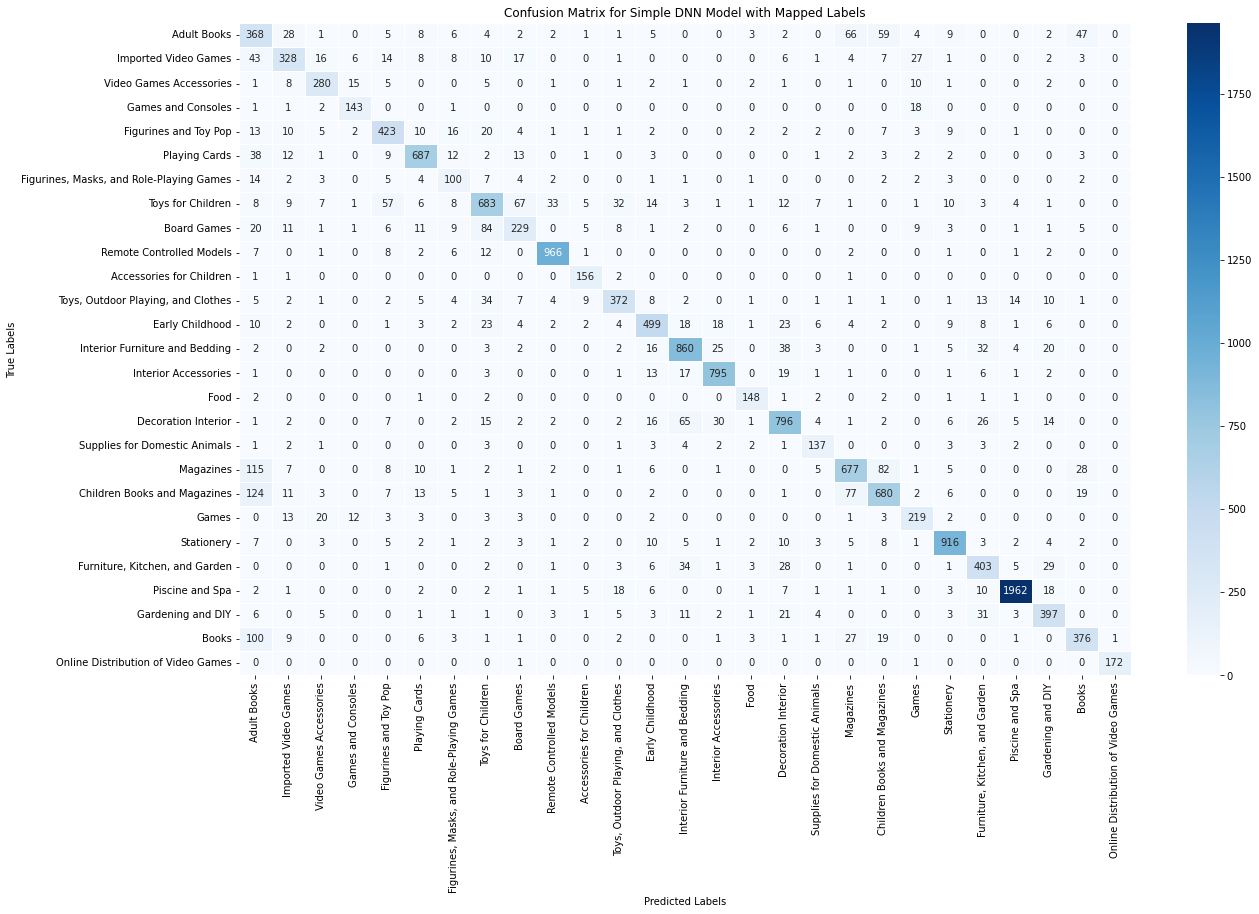

In [16]:
import importlib
importlib.reload(config)  # Reload config to ensure any updates are applied
import src.modeling_text.text_model_evaluation  # Initial import

importlib.reload(src.modeling_text.text_model_evaluation)  # Force reload the module
from src.modeling_text.text_model_evaluation import generate_confusion_matrix  

# Generate the confusion matrix with mapped labels
conf_matrix_df_labeled = generate_confusion_matrix(y_val, y_pred_classes, config.PRDTYPECODE_MAPPING_PATH)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(conf_matrix_df_labeled, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for Simple DNN Model with Mapped Labels")
plt.show()


### 5.3.2 Breakdown of Misclassifications  
→ **Analyze misclassification trends, identify the most frequently misclassified classes, and assess overall model performance.**  

In this section, we analyze the model’s misclassification patterns using a structured approach.  
We present four breakdowns to understand where the model struggles the most.  

#### **Columns in the Misclassification Table:**  
- **Encoded target** → The encoded numerical representation of each class.  
- **Original prdtypecode** → The original product category code.  
- **Class Label** → The human-readable label of the class.  
- **Samples** → The total number of instances for each class.  
- **Misclassified Count** → The number of misclassified samples for the class.  
- **Misclassification Rate (%)** → The percentage of misclassified samples within the class.  
- **Global Misclassification Rate (%)** → The percentage of misclassified samples relative to the total dataset.  

####  **Key Misclassification Perspectives**  

1. **Classes with the highest number of samples**  
   - Shows the most **frequent classes** in the dataset.  
   - Helps assess whether a class’s misclassification is due to **its high occurrence** or **its inherent difficulty**.  
   - Large classes can dominate misclassification counts even if their misclassification rate is low.  

2. **Classes with the highest number of misclassifications**  
   - Highlights the classes with the **largest absolute number of errors**.  
   - Useful for identifying which classes **contribute the most errors**, regardless of their misclassification rate.  
   - A class with many misclassifications may indicate **model weakness** or **data imbalance**.  

3. **Classes with the highest misclassification rate (%)**  
   - Identifies the classes where the model **struggles the most** proportionally.  
   - A high rate suggests **systematic confusion** in distinguishing this class from others.  
   - Small classes with a **high error rate** might require **better feature representation** or **more training data**.  

4. **Classes contributing the most to overall misclassification (%)**  
   - Measures **each class’s impact on total model errors**.  
   - A class with **many samples and a moderate error rate** can still contribute significantly to overall misclassification.  
   - Helps prioritize which classes should be improved to **reduce total model error** the most.  


By examining these four aspects, we gain insights into both **systematic classification errors** and **dataset imbalances** that could be influencing the model’s performance.  


In [17]:
import importlib

importlib.reload(config)
import src.modeling_text.text_model_evaluation  # Initial import
importlib.reload(src.modeling_text.text_model_evaluation)
from src.modeling_text.text_model_evaluation import analyze_and_display_misclassification

# Calculs déjà réalisés
misclassified_counts = conf_matrix_df_labeled.sum(axis=1) - np.diag(conf_matrix_df_labeled)
total_samples_per_class = conf_matrix_df_labeled.sum(axis=1)
misclassification_rates = round((misclassified_counts / total_samples_per_class) * 100, 2)

# [✔]Call the function with a custom number of rows to display
# You can set `display_rows` to control how many rows are shown in the notebook.
# By default, it displays 10 rows.
misclassification_analysis_df = analyze_and_display_misclassification(
    y_val, y_pred_classes, misclassified_counts, total_samples_per_class, misclassification_rates, display_rows=10
)


[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop


[✔] Misclassification analysis DataFrame created!

Top classes with the highest number of samples: (showing up to 10 rows)



,Encoded target,Original prdtypecode,Class Label,Samples,Misclassified Count,Misclassification Rate (%),Global Misclassification Rate (%)
23,23,2583,Piscine and Spa,2042,80,3.92,0.47
13,13,1560,Interior Furniture and Bedding,1015,155,15.27,0.91
9,9,1300,Remote Controlled Models,1009,43,4.26,0.25
16,16,2060,Decoration Interior,999,203,20.32,1.20
21,21,2522,Stationery,998,82,8.22,0.48
7,7,1280,Toys for Children,974,291,29.88,1.71
19,19,2403,Children Books and Magazines,955,275,28.80,1.62
18,18,2280,Magazines,952,275,28.89,1.62
14,14,1920,Interior Accessories,861,66,7.67,0.39
5,5,1160,Playing Cards,791,104,13.15,0.61



Top classes with the highest number of misclassifications: (showing up to 10 rows)



,Encoded target,Original prdtypecode,Class Label,Samples,Misclassified Count,Misclassification Rate (%),Global Misclassification Rate (%)
7,7,1280,Toys for Children,974,291,29.88,1.71
19,19,2403,Children Books and Magazines,955,275,28.80,1.62
18,18,2280,Magazines,952,275,28.89,1.62
0,0,10,Adult Books,623,255,40.93,1.50
16,16,2060,Decoration Interior,999,203,20.32,1.20
8,8,1281,Board Games,414,185,44.69,1.09
25,25,2705,Books,552,176,31.88,1.04
1,1,40,Imported Video Games,502,174,34.66,1.02
13,13,1560,Interior Furniture and Bedding,1015,155,15.27,0.91
12,12,1320,Early Childhood,648,149,22.99,0.88



Top classes with the highest misclassification rate (%): (showing up to 10 rows)



,Encoded target,Original prdtypecode,Class Label,Samples,Misclassified Count,Misclassification Rate (%),Global Misclassification Rate (%)
8,8,1281,Board Games,414,185,44.69,1.09
0,0,10,Adult Books,623,255,40.93,1.50
1,1,40,Imported Video Games,502,174,34.66,1.02
6,6,1180,"Figurines, Masks, and Role-Playing Games",153,53,34.64,0.31
25,25,2705,Books,552,176,31.88,1.04
7,7,1280,Toys for Children,974,291,29.88,1.71
18,18,2280,Magazines,952,275,28.89,1.62
19,19,2403,Children Books and Magazines,955,275,28.80,1.62
11,11,1302,"Toys, Outdoor Playing, and Clothes",498,126,25.30,0.74
12,12,1320,Early Childhood,648,149,22.99,0.88



Top classes contributing the most to overall misclassification (%): (showing up to 10 rows)



,Encoded target,Original prdtypecode,Class Label,Samples,Misclassified Count,Misclassification Rate (%),Global Misclassification Rate (%)
7,7,1280,Toys for Children,974,291,29.88,1.71
19,19,2403,Children Books and Magazines,955,275,28.80,1.62
18,18,2280,Magazines,952,275,28.89,1.62
0,0,10,Adult Books,623,255,40.93,1.50
16,16,2060,Decoration Interior,999,203,20.32,1.20
8,8,1281,Board Games,414,185,44.69,1.09
25,25,2705,Books,552,176,31.88,1.04
1,1,40,Imported Video Games,502,174,34.66,1.02
13,13,1560,Interior Furniture and Bedding,1015,155,15.27,0.91
12,12,1320,Early Childhood,648,149,22.99,0.88


### 5.3.3 Detailed Misclassification Statistics  
→ **Analyze individual misclassification cases, including total errors, misclassification rates, and overprediction trends.**  

####  Meaning of Columns in the Classification Error Analysis Table  

| **Column**                | **Description** |
|---------------------------|----------------|
| **True Label**            | The actual class of the sample in the test set (the correct category). |
| **Predicted Label**       | The incorrect class predicted by the model instead of the **True Label**. |
| **Count**                 | The number of times samples from **True Label** were misclassified as **Predicted Label**. |
| **Percentage**            | The proportion of this specific misclassification relative to **all misclassified instances**. Computed as: `(Count / Total Misclassified) * 100`. |
| **Class Sample Size** | The total number of test samples belonging to the **True Label** class (i.e., how many instances of this class exist in the test set). |
| **Misclassified Count**   | The total number of **True Label** samples that were misclassified (sum of all errors for this class). |
| **Misclassification Rate** | The error rate for the **True Label** class. Computed as: `(Misclassified Count /Class Sample Size) * 100`. |
| **Total Predicted**       | The total number of test samples predicted as belonging to the **Predicted Label** class (both correctly and incorrectly). |
| **Incorrect Predictions** | The number of test samples **incorrectly predicted** as **Predicted Label** (should have been a different class). |
| **Overprediction Rate**   | The proportion of incorrect predictions for the **Predicted Label** class. Computed as: `(Incorrect Predictions / Total Predicted) * 100`. |



In [18]:
importlib.reload(config) 
import src.modeling_text.text_model_evaluation  # Initial import
importlib.reload(src.modeling_text.text_model_evaluation)  # Force reload to use updated functions
from src.modeling_text.text_model_evaluation import generate_display_misclass_report

# Generate the enriched misclassification report
# NOTE: To display only a subset of rows, modify display_rows when calling the function
# Example: Use display_rows=20 to show only the top 20 rows:
misclassification_report = generate_display_misclass_report(
    y_val, y_pred_classes, config.PRDTYPECODE_MAPPING_PATH, display_rows=20 # Set top_n to an integer (e.g., 20) to limit rows
)

# # Display the final enriched report
# print("\n[✔] Consolidated Misclassification Report:")
# display(misclassification_report)

[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop



Misclassification Report: (showing up to 20 rows)



,True Label,Predicted Label,Count,Percentage,Class Sample Size,Misclassified Count,Misclassification Rate,Total Predicted,Incorrect Predictions,Overprediction Rate
0,Children Books and Magazines,Adult Books,124,3.86%,955,275,28.80%,890,522,58.65%
1,Magazines,Adult Books,115,3.58%,952,275,28.89%,890,522,58.65%
2,Books,Adult Books,100,3.11%,552,176,31.88%,890,522,58.65%
3,Board Games,Toys for Children,84,2.62%,414,185,44.69%,924,241,26.08%
4,Magazines,Children Books and Magazines,82,2.55%,952,275,28.89%,878,198,22.55%
5,Children Books and Magazines,Magazines,77,2.40%,955,275,28.80%,873,196,22.45%
6,Toys for Children,Board Games,67,2.09%,974,291,29.88%,364,135,37.09%
7,Adult Books,Magazines,66,2.05%,623,255,40.93%,873,196,22.45%
8,Decoration Interior,Interior Furniture and Bedding,65,2.02%,999,203,20.32%,1023,163,15.93%
9,Adult Books,Children Books and Magazines,59,1.84%,623,255,40.93%,878,198,22.55%



[✔] Final Consolidated Report Generated!


### 5.4 **Exporting Classification Analysis to Excel** 

This step saves all classification insights into a **single Excel file** with multiple sheets for easy review.  

####  Exported Data Includes:
- **Well-Classified, Moderately Classified, Poorly Classified** categories (sorted by F1-score).  
- **Misclassification Analysis** (error rates, misclassified counts).  
- **Consolidated Misclassification Report** (detailed misclassification breakdown per class).  
- **Raw Confusion Matrix** (numerical values without labels).  

####  Output File Example:  
**`classification_analysis_<MODEL_NAME>_<TIMESTAMP>.xlsx`**  



In [19]:
import importlib
import src.modeling_text.text_model_evaluation  # Initial import
import utils.report_export  # # Initial import

importlib.reload(config) # Force reload module
importlib.reload(src.modeling_text.text_model_evaluation)  # Force reload module
importlib.reload(utils.report_export)  # Force reload module

from src.modeling_text.text_model_evaluation import analyze_and_display_misclassification, generate_display_misclass_report
from utils.report_export import export_all_analysis




# Define model name and file prefix
model_used = "Simple_DNN_Model"
file_prefix = "classification_analysis"

# Generate and process the classification report
classification_df, summary_rows, accuracy_value, accuracy_support = process_classification_report(
    y_val, y_pred_classes, config.PRDTYPECODE_MAPPING_PATH
)


# # Convert conf_matrix_df_raw to Pandas DataFrame
# conf_matrix_df = pd.DataFrame(conf_matrix_df_raw, 
#                               index=[f"True Class {label}" for label in set(y_val)],  # Index as True Labels
#                               columns=[f"Pred Class {label}" for label in set(y_pred_classes)])  # Columns as Predicted Labels

conf_matrix_df = pd.DataFrame(
    conf_matrix_df_raw,
    index=[f"True Class {i}" for i in range(27)],
    columns=[f"Pred Class {i}" for i in range(27)]
)


# Generates and displays misclassification analysis
full_misclassification_analysis_df = analyze_and_display_misclassification(y_val,
                                                                           y_pred_classes,
                                                                           misclassified_counts,
                                                                           total_samples_per_class,
                                                                           misclassification_rates,
                                                                           display_rows=None,
                                                                           display_output=False
)

#Generates and displays a comprehensive misclassification report combining multiple analyses
full_misclassification_report = generate_display_misclass_report(y_val,
                                                                 y_pred_classes,
                                                                 config.PRDTYPECODE_MAPPING_PATH,
                                                                 display_rows=None,
                                                                display_output=False
)



dataframes_to_export = {
    "Class Categorization": {
        f"Well-Classified (F1 ≥ {WELL_CLASSIFIED_THRESHOLD:.2f})": well_classified.sort_values(by="f1-score", ascending=False),
        f"Moderately Classified ({MODERATELY_CLASSIFIED_THRESHOLD:.2f} ≤ F1 < {WELL_CLASSIFIED_THRESHOLD:.2f})": moderately_classified.sort_values(by="f1-score", ascending=False),
        f"Poorly Classified (F1 < {MODERATELY_CLASSIFIED_THRESHOLD:.2f})": poorly_classified.sort_values(by="f1-score", ascending=True),
    },
    "Misclassification Analysis": full_misclassification_analysis_df,
    "Consolidated Misclassification Report": full_misclassification_report,
    "Raw Confusion Matrix": conf_matrix_df
}

# Export all the data
export_path = export_all_analysis(
    dataframes_dict=dataframes_to_export,
    model_name=model_used,
    file_prefix=file_prefix,
    mode="text",
    classification_df=classification_df,
    summary_rows=summary_rows,
    accuracy_value=accuracy_value,
    accuracy_support=accuracy_support
)

# Print confirmation
print(f"\n[✔] Full classification analysis saved to: {export_path}")

[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop


[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop


[✔] Misclassification analysis DataFrame created!
[DEBUG] Loading label mapping from: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl
[✔] Successfully loaded label mapping from D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\data\processed\prdtypecode_mapping.pkl | Type: <class 'pandas.core.frame.DataFrame'>
[DEBUG] First few rows of the mapping DataFrame:


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books
1,40,1,Imported Video Games
2,50,2,Video Games Accessories
3,60,3,Games and Consoles
4,1140,4,Figurines and Toy Pop



[✔] Final Consolidated Report Generated!

[✔] Full classification analysis saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\reports\classification_reports\text\classification_analysis_Simple_DNN_Model_2025-04-14_18-05-47.xlsx
